# Week 1 Integrated Mini-Notebook

## Titanic Passenger Data Analysis

This notebook is the final practical task for Week 1 of the BinX Tech AI and Machine Learning Internship.

The project combines the main tools covered during the week:

- NumPy for numerical operations
- Pandas for loading, cleaning, and analyzing tabular data
- Matplotlib for creating visualizations
- Jupyter Notebook for combining code, outputs, and explanations

The Titanic dataset will be loaded and processed again inside this notebook. This makes the project independent from the previous Pandas notebook and allows it to run from beginning to end on its own.

## Project Objective

The goal of this project is to follow a basic data analysis workflow using a real dataset.

The workflow includes:

1. Loading and inspecting the data
2. Checking data quality
3. Cleaning missing values and duplicate rows
4. Creating a useful feature with NumPy
5. Filtering and grouping the data
6. Creating labeled visualizations
7. Writing conclusions based on the actual results

## Analysis Questions

This project will try to answer the following questions:

1. What does the age distribution of the passengers look like?
2. Is there a visible relationship between passenger age and ticket fare?
3. How does the survival rate differ between passenger classes?
4. How does the survival rate differ between male and female passengers?
5. Did passengers travelling alone have a different survival rate from passengers travelling with family?
6. What is the average ticket fare for each passenger class?

## 1. Importing the Required Libraries

This project uses the three main data science libraries covered during Week 1:

- NumPy for numerical operations and feature creation
- Pandas for loading, cleaning, filtering, and analyzing the dataset
- Matplotlib for creating visualizations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Loading the Dataset

The Titanic dataset is stored inside the `data` folder.

Pandas will load the CSV file into a DataFrame named `df`. The first five rows will then be displayed to confirm that the dataset was loaded correctly.

In [2]:
df = pd.read_csv("data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Initial Dataset Inspection

Before cleaning or changing the data, I will inspect its size, columns, data types, and summary statistics.

This step helps me understand the structure of the dataset and identify possible data quality problems.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 891
Number of columns: 12

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 4. Understanding the Main Columns

The dataset contains information about Titanic passengers.

| Column | Description |
|---|---|
| PassengerId | Unique passenger identifier |
| Survived | Survival status: 0 means no, 1 means yes |
| Pclass | Passenger class: 1st, 2nd, or 3rd class |
| Name | Passenger name |
| Sex | Passenger sex |
| Age | Passenger age |
| SibSp | Number of siblings or spouses on board |
| Parch | Number of parents or children on board |
| Ticket | Ticket number |
| Fare | Ticket fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation: C, Q, or S |

## 5. Checking Data Quality

Real datasets may contain missing values, duplicate rows, or unsuitable data types.

In this section, I will check:

- Missing values in each column
- The percentage of missing data
- Duplicate rows
- Current data types
- Unique values in important categorical columns

In [6]:
missing_summary = pd.DataFrame({
    "MissingValues": df.isna().sum(),
    "MissingPercentage": (df.isna().mean() * 100).round(2)
})
missing_summary = missing_summary.sort_values(
    by="MissingValues",
    ascending=False
)
missing_summary[missing_summary["MissingValues"] > 0]

,MissingValues,MissingPercentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
categorical_columns = ["Survived", "Pclass", "Sex", "Embarked"]
for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

Survived: [0 1]
Pclass: [3 1 2]
Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
Embarked: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


### Data Quality Notes

The numeric columns already have suitable numeric data types, while the text columns are stored as strings.

The categorical values are consistent, so no data type conversion is required. The main data quality problems are the missing values in `Age`, `Cabin`, and `Embarked`.

## 6. Data Cleaning

The initial inspection shows that some columns need cleaning.

The following decisions will be applied:

- Missing `Age` values will be filled with the median age because the median is less affected by unusually high or low values.
- Missing `Embarked` values will be filled with the most common value.
- The `Cabin` column will be removed because a large part of it is missing.
- Duplicate rows will be removed if any are found.
- The index will be reset after cleaning.

In [10]:
age_median = df["Age"].median()
embarked_mode = df["Embarked"].mode()[0]
print("Median age:", age_median)
print("Most common embarkation port:", embarked_mode)

Median age: 28.0
Most common embarkation port: S


In [11]:
rows_before_cleaning = df.shape[0]
df["Age"] = df["Age"].fillna(age_median)
df["Embarked"] = df["Embarked"].fillna(embarked_mode)
df = df.drop(columns=["Cabin"])
df = df.drop_duplicates()
df = df.reset_index(drop=True)
rows_after_cleaning = df.shape[0]
print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print("Removed duplicate rows:", rows_before_cleaning - rows_after_cleaning)

Rows before cleaning: 891
Rows after cleaning: 891
Removed duplicate rows: 0


## 7. Verifying the Cleaning Results
After cleaning the dataset, I will check the missing values and duplicate rows again.
This verification is important because it confirms that the cleaning steps worked as expected.

In [12]:
print("Missing values after cleaning:")
print(df.isna().sum())
print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())
print("\nCleaned dataset shape:")
print(df.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicate rows after cleaning:
0

Cleaned dataset shape:
(891, 11)


## 8. Creating New Features with NumPy
The `SibSp` and `Parch` columns describe how many family members travelled with each passenger.
I will use NumPy to create two useful features:
- `FamilySize`: the total number of family members including the passenger
- `IsAlone`: whether the passenger travelled alone or with family

In [13]:
siblings_spouses = df["SibSp"].to_numpy()
parents_children = df["Parch"].to_numpy()
df["FamilySize"] = np.add(siblings_spouses,parents_children) + 1
df["IsAlone"] = np.where(
    df["FamilySize"] == 1,
    "Yes",
    "No"
)
df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,No
1,1,0,2,No
2,0,0,1,Yes
3,1,0,2,No
4,0,0,1,Yes
5,0,0,1,Yes
6,0,0,1,Yes
7,3,1,5,No
8,0,2,3,No
9,1,0,2,No


In [14]:
fare_array = df["Fare"].to_numpy()
mean_fare = np.mean(fare_array)
median_fare = np.median(fare_array)
print("Mean fare:", round(mean_fare, 2))
print("Median fare:", round(median_fare, 2))

Mean fare: 32.2
Median fare: 14.45


## 9. Filtering the Dataset
Filtering allows me to focus on passengers who match a specific condition.
In this section, I will examine passengers who paid more than the average ticket fare.

In [15]:
above_average_fare = df.loc[
    df["Fare"] > mean_fare,
    ["PassengerId", "Name", "Pclass", "Fare", "Survived"]
].sort_values(
    by="Fare",
    ascending=False
)
print("Passengers who paid more than the average fare:")
print(above_average_fare.shape[0])
above_average_fare.head(10)

Passengers who paid more than the average fare:
211


,PassengerId,Name,Pclass,Fare,Survived
258,259,"Ward, Miss. Anna",1,512.3292,1
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
737,738,"Lesurer, Mr. Gustave J",1,512.3292,1
341,342,"Fortune, Miss. Alice Elizabeth",1,263.0000,1
438,439,"Fortune, Mr. Mark",1,263.0000,0
88,89,"Fortune, Miss. Mabel Helen",1,263.0000,1
27,28,"Fortune, Mr. Charles Alexander",1,263.0000,0
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750,1
311,312,"Ryerson, Miss. Emily Borie",1,262.3750,1
118,119,"Baxter, Mr. Quigg Edmond",1,247.5208,0


## 10. Grouping and Aggregation

Grouping helps compare different passenger categories.

Because the `Survived` column contains 0 and 1, its mean represents the survival rate:

- 0 means the passenger did not survive
- 1 means the passenger survived

The mean will be multiplied by 100 to display the result as a percentage.

In [16]:
survival_by_class = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)
survival_by_class

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

In [17]:
survival_by_sex = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

survival_by_sex

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [18]:
survival_by_alone = (
    df.groupby("IsAlone")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)
survival_by_alone

IsAlone
No     50.56
Yes    30.35
Name: Survived, dtype: float64

In [19]:
average_fare_by_class = (
    df.groupby("Pclass")["Fare"]
    .mean()
    .round(2)
)
average_fare_by_class

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

## 11. Data Visualization

The cleaned dataset will now be explored using Matplotlib.

The visualizations include:

1. A histogram of passenger ages
2. A scatter plot of age and ticket fare
3. A bar plot of survival rate by passenger class
4. Subplots comparing survival rate by sex and travelling status

Each plot includes a clear title and axis labels.

### 11.1 Passenger Age Distribution

A histogram will be used to examine how passenger ages are distributed across the dataset.

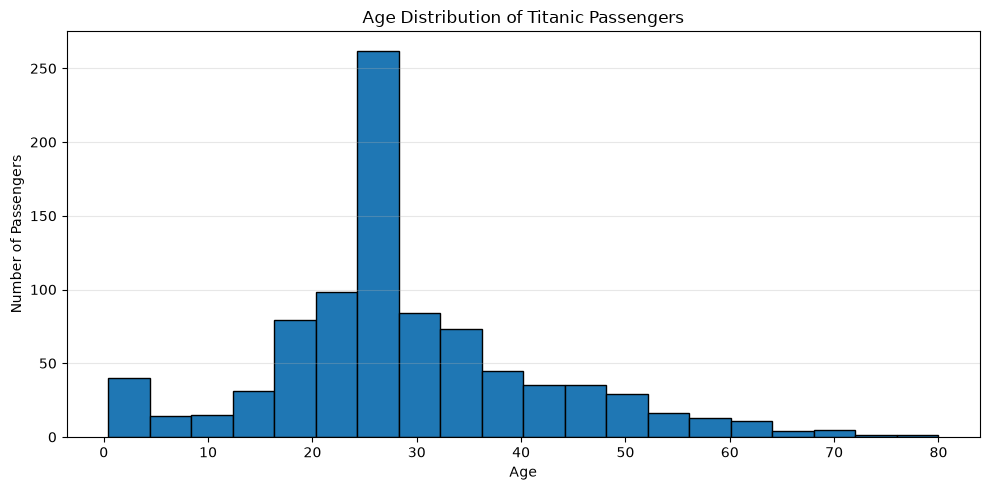

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)
ax.set_title("Age Distribution of Titanic Passengers")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Passengers")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation

The histogram shows that many passengers were young adults, especially between about 20 and 35 years old.

There is a noticeable concentration around the age of 28. Part of this concentration is caused by filling the missing `Age` values with the median age of 28 during data cleaning.

The number of passengers generally decreases at older ages, and only a small number of passengers were above 60 years old.

#### Conclusion

Most Titanic passengers in this dataset were young or middle-aged adults. However, the large bar around age 28 should be interpreted carefully because missing ages were replaced with the median.

### 11.2 Relationship Between Age and Ticket Fare

A scatter plot will be used to examine whether passenger age has a visible relationship with ticket fare.

Survived and non-survived passengers will be displayed separately.

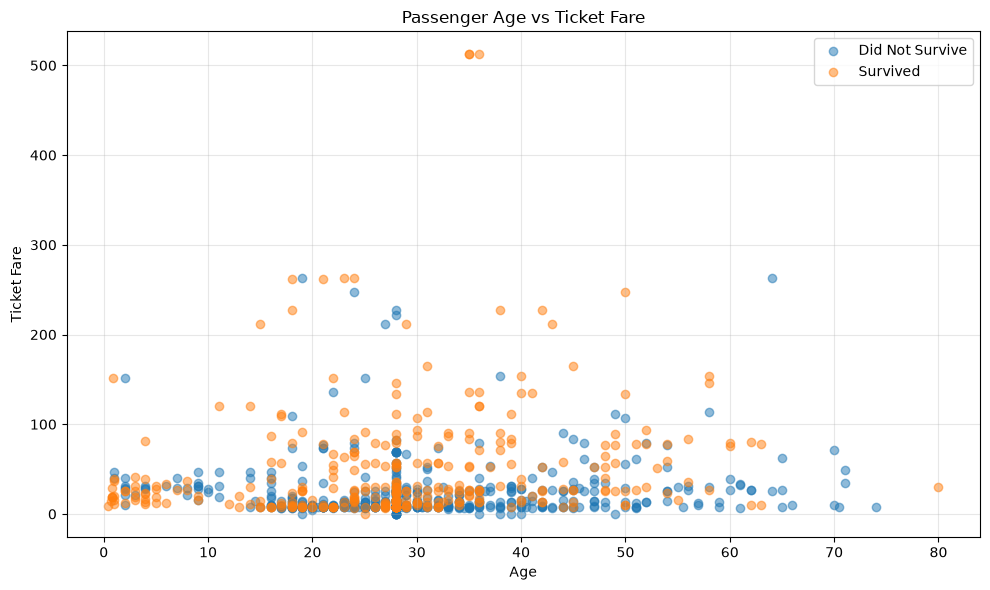

In [21]:
survived_passengers = df[df["Survived"] == 1]
not_survived_passengers = df[df["Survived"] == 0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    not_survived_passengers["Age"],
    not_survived_passengers["Fare"],
    alpha=0.5,
    label="Did Not Survive"
)

ax.scatter(
    survived_passengers["Age"],
    survived_passengers["Fare"],
    alpha=0.5,
    label="Survived"
)

ax.set_title("Passenger Age vs Ticket Fare")
ax.set_xlabel("Age")
ax.set_ylabel("Ticket Fare")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation

Most passengers paid fares below 100, and this pattern appears across different ages.

There is no clear linear relationship between passenger age and ticket fare. Passengers of similar ages sometimes paid very different fares.

The plot also contains a few unusually high fare values, including fares above 200 and 500. Both survived and non-survived passengers appear across the main range, although several of the highest-fare passengers survived.

#### Conclusion

Passenger age alone does not appear to explain the ticket fare. Passenger class appears to be more relevant because the average fare was much higher in first class than in second and third class.

### 11.3 Survival Rate by Passenger Class

A bar plot will compare the survival percentage of first, second, and third class passengers.

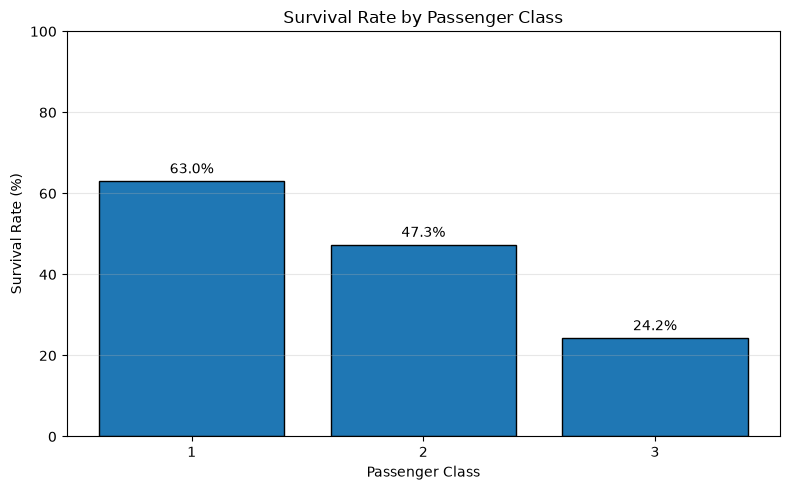

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values,
    edgecolor="black"
)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
for index, value in enumerate(survival_by_class.values):
    ax.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )
plt.tight_layout()
plt.show()

#### Observation

The survival rate decreases as passenger class changes from first class to third class.

- First class had a survival rate of about 63.0%.
- Second class had a survival rate of about 47.3%.
- Third class had a survival rate of about 24.2%.

The difference between first and third class is large.

#### Conclusion

Passenger class was strongly associated with survival in this dataset. First-class passengers had the highest survival rate, while third-class passengers had the lowest.

### 11.4 Survival Comparison
Two bar plots will be displayed in one figure:

- Survival rate by sex
- Survival rate for passengers travelling alone or with family

Using subplots makes it easier to compare multiple results in one figure.

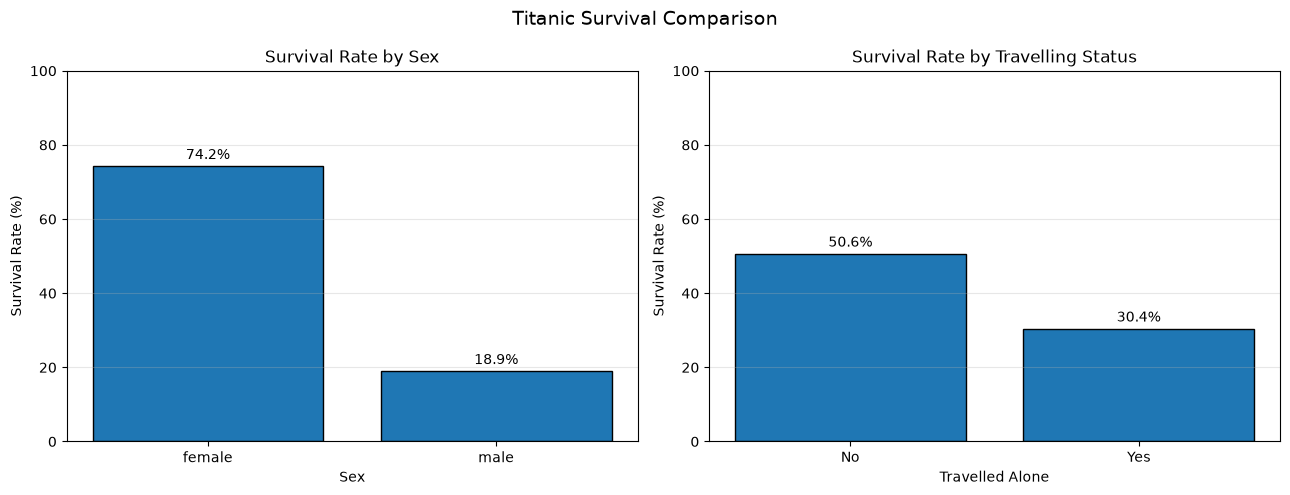

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].bar(
    survival_by_sex.index,
    survival_by_sex.values,
    edgecolor="black"
)

axes[0].set_title("Survival Rate by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(axis="y", alpha=0.3)

for index, value in enumerate(survival_by_sex.values):
    axes[0].text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )


axes[1].bar(
    survival_by_alone.index,
    survival_by_alone.values,
    edgecolor="black"
)

axes[1].set_title("Survival Rate by Travelling Status")
axes[1].set_xlabel("Travelled Alone")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)

for index, value in enumerate(survival_by_alone.values):
    axes[1].text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

fig.suptitle(
    "Titanic Survival Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Observation

Female passengers had a much higher survival rate than male passengers:

- Female survival rate: about 74.2%
- Male survival rate: about 18.9%

Passengers who travelled with family also had a higher survival rate than passengers who travelled alone:

- Travelled with family: about 50.6%
- Travelled alone: about 30.4%

#### Conclusion

Sex and travelling status were both associated with survival in this dataset. Female passengers had a much higher survival rate, and passengers travelling with family survived at a higher rate than passengers travelling alone.

## 12. Final Findings

The main findings from this analysis are:

1. The dataset originally contained missing values in `Age`, `Cabin`, and `Embarked`.
2. `Cabin` had about 77% missing values, so it was removed from the analysis.
3. Missing ages were filled with the median age of 28, while missing embarkation values were filled with `S`, the most common port.
4. No duplicate rows were found in the dataset.
5. The mean ticket fare was 32.20, while the median was 14.45. This difference indicates that a smaller number of high fares increased the mean.
6. A total of 211 passengers paid more than the average fare.
7. The average fare was 84.15 for first-class passengers, 20.66 for second-class passengers, and 13.68 for third-class passengers.
8. First-class passengers had the highest survival rate at about 63%, while third-class passengers had the lowest at about 24%.
9. Female passengers had a much higher survival rate than male passengers.
10. Passengers travelling with family had a higher survival rate than passengers travelling alone.
11. The scatter plot did not show a clear relationship between passenger age and ticket fare.

## 13. Conclusion

This project followed a complete basic data analysis workflow using the Titanic dataset.

Pandas was used to load, inspect, clean, filter, and group the data. NumPy was used to perform numerical operations and create the `FamilySize` and `IsAlone` features. Matplotlib was used to explore the data using a histogram, scatter plot, bar plot, and subplots.

The analysis showed clear differences in survival rates across passenger class, sex, and travelling status. It also showed that passenger age did not have a clear visual relationship with ticket fare.

This notebook does not build a machine learning model. Its purpose is to combine the main tools and skills covered during Week 1 in one independent and reproducible analysis.